# JET Global Sensitivity Analysis with SALib (Sobol Indices)

This notebook performs a Global Sensitivity Analysis (GSA) of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data and **Sobol indices** via the `SALib` package. It computes first-order ($S_1$) and total-order ($S_T$) indices to rigorously quantify the fractional variance each input variable contributes to model outputs like latent heat flux and evapotranspiration.

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import SALib modules for Global Sensitivity Analysis
from SALib.sample import saltelli
from SALib.analyze import sobol

# Custom JET modules
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs

## Configuration and Problem Setup
Define the variables of interest and their corresponding physical boundaries to build the multi-dimensional parameter space for the Sobol evaluation.

In [3]:
SAVE_PLOTS = False

input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH", 
    "AOT", "COT", "vapor_gccm", "ozone_cm", 
    "elevation_m", "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2", "ET_daylight_kg", "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to generate the Sobol parameter space
input_min = {
    "ST_C": 0.0, "NDVI": 0.05, "albedo": 0.0, "Ta_C": 0.0, 
    "RH": 0.0, "AOT": 0.0, "COT": 0.0, "vapor_gccm": 0.0, 
    "ozone_cm": 0.0, "elevation_m": 0.0, "canopy_height_meters": 0.0
}

# Maximums are required for SALib uniform sampling limits.
input_max = {
    "ST_C": 50.0, "NDVI": 1.0, "albedo": 1.0, "Ta_C": 50.0, 
    "RH": 1.0, "AOT": 2.0, "COT": 100.0, "vapor_gccm": 5.0, 
    "ozone_cm": 0.5, "elevation_m": 5000.0, "canopy_height_meters": 50.0
}

## Load and Format Baseline Data
We load the baseline data primarily to retain the geometric, temporal, and climate-specific string/classification requirements for the forward model run.

In [4]:
# Load baseline data
input_df = load_ECOv002_calval_JET_inputs()

mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask].dropna()

## Generate Saltelli Samples
Construct the problem dictionary and utilize Saltelli's extension of the Sobol sequence to generate parameter values.

In [5]:
problem = {
    'num_vars': len(input_variables),
    'names': input_variables,
    'bounds': [[input_min[var], input_max[var]] for var in input_variables]
}

# Generate Saltelli samples. Total iterations = N * (2D + 2)
# With D=11 and N=256, total model evaluations will be 6,144.
N = 256 
param_values = saltelli.sample(problem, N, calc_second_order=True)

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_49203/65101988.py:10: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


## Process Samples via the JET Model
We broadcast a static base row from the dataframe to match the Saltelli matrix size, overwrite our input variables with the generated samples, and execute the forward run.

In [6]:
# Construct a sampled DataFrame by repeating a base row
base_row = input_df.iloc[0:1]
sampled_df = pd.concat([base_row] * param_values.shape[0], ignore_index=True)

# Inject the perturbed Sobol variables into the DataFrame
sampled_df[input_variables] = param_values
print(f"Executing {param_values.shape[0]} runs for Global Sensitivity Analysis...")

# Run the forward process
processed_samples = process_JET_table(sampled_df)

Executing 6144 runs for Global Sensitivity Analysis...
[2026-08-06 13:14:19 INFO] starting JET table processing
[2026-08-06 13:14:19 INFO] started extracting geometry from JET input table
[2026-08-06 13:14:19 INFO] completed extracting geometry from JET input table (0.051 seconds)
[2026-08-06 13:14:19 INFO] started extracting time from JET input table
[2026-08-06 13:14:19 INFO] completed extracting time from JET input table (0.004 seconds)
[2026-08-06 13:14:19 INFO] running Forest Light Environmental Simulator
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step
[2026-08-06 13:14:20 INFO] completed processing FLiES-ANN in 0.43 seconds
[2026-08-06 13:14:20 INFO] variable PAR_albedo (float64) with [0.02121929] unique values
[2026-08-06 13:14:20 INFO] * 0.021219292649443: 6144
[2026-08-06 13:14:20 INFO] variable NIR_albedo (float64) with [0.1110699] unique values
[2026-08-06 13:14:20 INFO] * 0.1110699046857625: 6144
[2026-08-06 13:14:20 INFO] variable PAR_direct_Wm2 min: 0.371 mean: 11.290 max: 195

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

[2026-08-06 13:14:21 INFO] completed daylight ET upscaling (elapsed: 0.17 seconds)
[2026-08-06 13:14:21 INFO] PT-JPL-SM model run complete (elapsed: 0.20 seconds)
[2026-08-06 13:14:21 INFO] completed processing PT-JPL-SM in 0.20 seconds
[2026-08-06 13:14:21 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 39.767 max: 616.093 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 0.587 max: 8.949 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable G_PTJPLSM min: 0.000 mean: 4.645 max: 84.846 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.353 max: 1.123 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 9.346 max: 212.744 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.000 mean: 0.284 max: 0.999 nan: 53.42% (nan)
[2026-08-06 13:14:21 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 22.561 max: 472.178 nan: 1.17% (nan)
[2026-08-06 13:1

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a spe

[2026-08-06 13:14:21 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-06 13:14:21 INFO] completed processing PM-JPL in 0.24 seconds
[2026-08-06 13:14:21 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 32.865 max: 524.283 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 0.488 max: 7.810 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 4.645 max: 84.846 nan: 1.17% (nan)
[2026-08-06 13:14:21 INFO] variable ET_daylight_kg min: 0.000 mean: 0.574 max: 8.379 nan: 0.00% (nan)
[2026-08-06 13:14:21 INFO] JET table processing complete (1.805 seconds)


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

## Analyze and Visualize Sobol Indices
We extract the target array, analyze the outputs via the Sobol library, and map the First-Order and Total-Order variance percentages into a comparison chart.

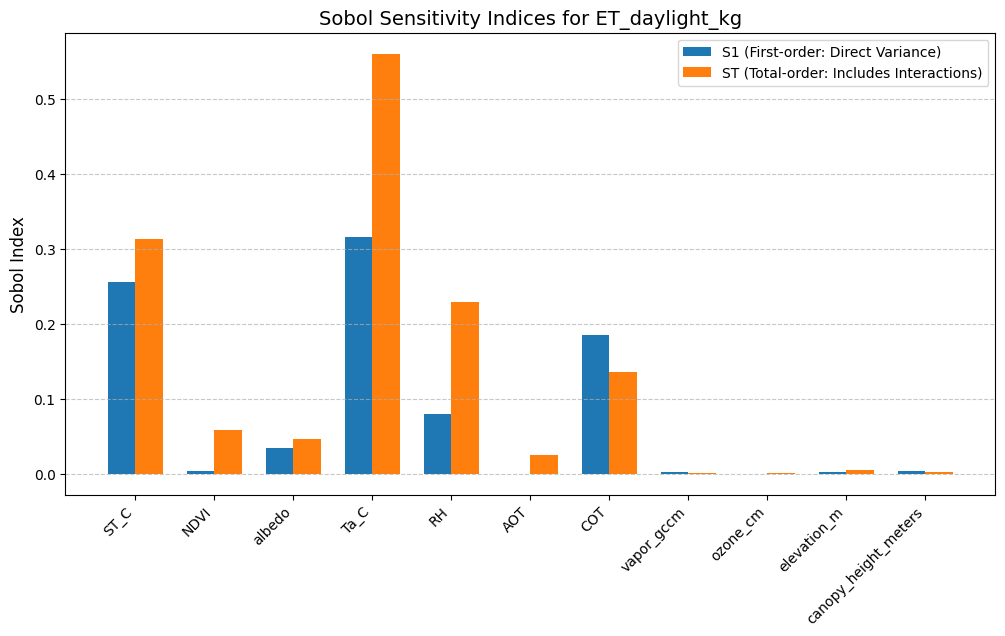

In [7]:
target_output = "ET_daylight_kg"
Y = processed_samples[target_output].values

# Calculate Sobol indices
Si = sobol.analyze(problem, Y, calc_second_order=True)

# Visualizing First-Order and Total-Order Indices
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(input_variables))
width = 0.35

ax.bar(x - width/2, Si['S1'], width, label='S1 (First-order: Direct Variance)')
ax.bar(x + width/2, Si['ST'], width, label='ST (Total-order: Includes Interactions)')

ax.set_ylabel('Sobol Index', fontsize=12)
ax.set_title(f'Sobol Sensitivity Indices for {target_output}', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(input_variables, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

if SAVE_PLOTS:
    plt.savefig('sobol_sensitivity_indices.png', dpi=300, bbox_inches='tight')
plt.show()